Import Data and Load

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [6]:
df = pd.read_csv('/Users/kabindradhakal/Documents/python projects/data/student.csv')
# Drop G1, G2, G3 to avoid leakage — keep only behavioral / demographic features.
leakage = [c for c in ['G1', 'G2', 'G3'] if c in df.columns]
df = df.drop(columns=leakage)
print('Shape:', df.shape)
df.head()

Shape: (1044, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,course,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,math,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,math,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,math,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,math,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,math,1


Dataset Overview

In [7]:
df.dtypes.value_counts()

str      18
int64    14
Name: count, dtype: int64

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,1044,2,GP,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1044,2,F,591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1044.0,NaN,NaN,NaN,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
address,1044,2,U,759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,1044,2,GT3,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,1044,2,T,923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,1044.0,NaN,NaN,NaN,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,NaN,NaN,NaN,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
Mjob,1044,5,other,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,1044,5,other,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 0
Memory (MB): 1.05


Missing Values

In [10]:
missing_df = (
    df.isna()
      .sum()
      .to_frame(name='Missing')
      .assign(
          Percent=lambda x: (x['Missing'] / len(df) * 100).round(2),
          Dtype=df.dtypes
      )
      .query('Missing > 0')
      .sort_values(by='Missing', ascending=False)
)

print(missing_df if not missing_df.empty else 'No missing values found')

No missing values found


Univariate Analysis

In [11]:
numeric_cols = (
    df.select_dtypes(include='number')
      .columns
      .drop('passed', errors='ignore')
      .tolist()
)

print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (13):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


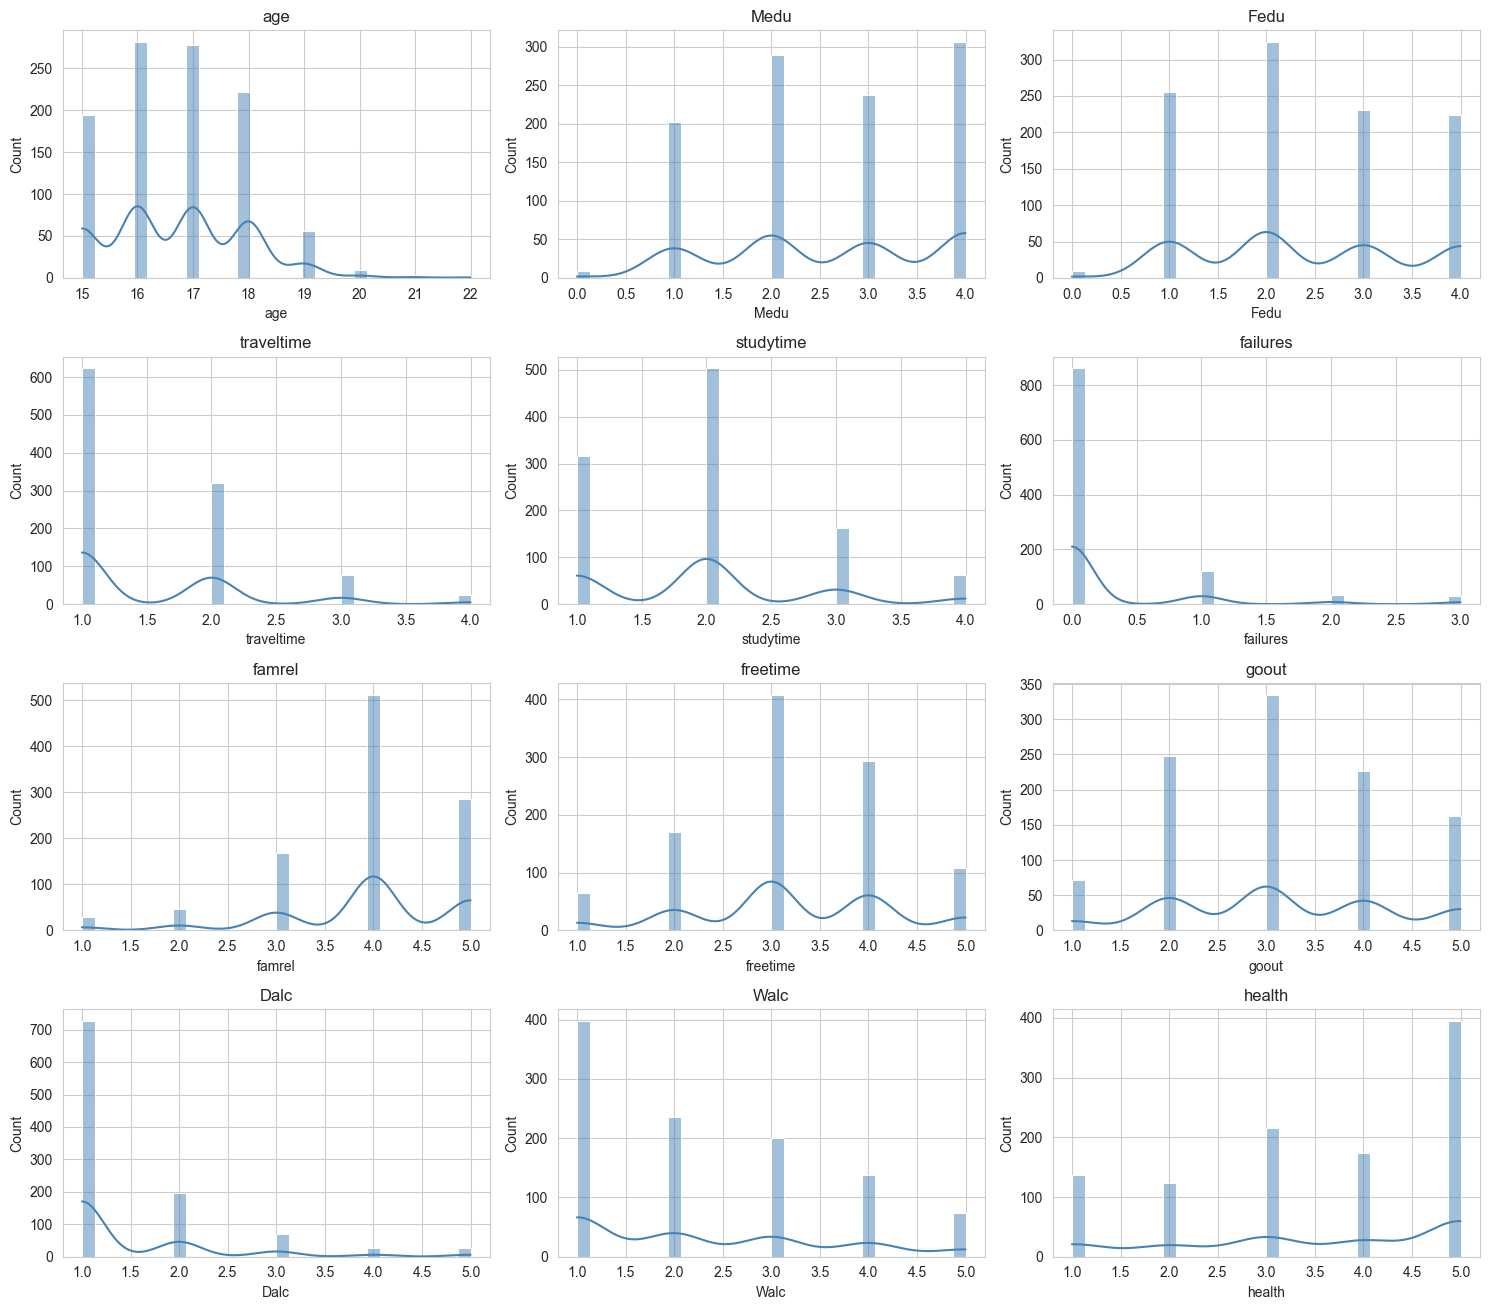

In [12]:
import math
import seaborn as sns

n_show = min(len(numeric_cols), 12)

ncols = 3
nrows = math.ceil(n_show / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(15, 3.3*nrows))

axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols[:n_show]):
    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 ax=axes[i],
                 color='steelblue')

    axes[i].set_title(col)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

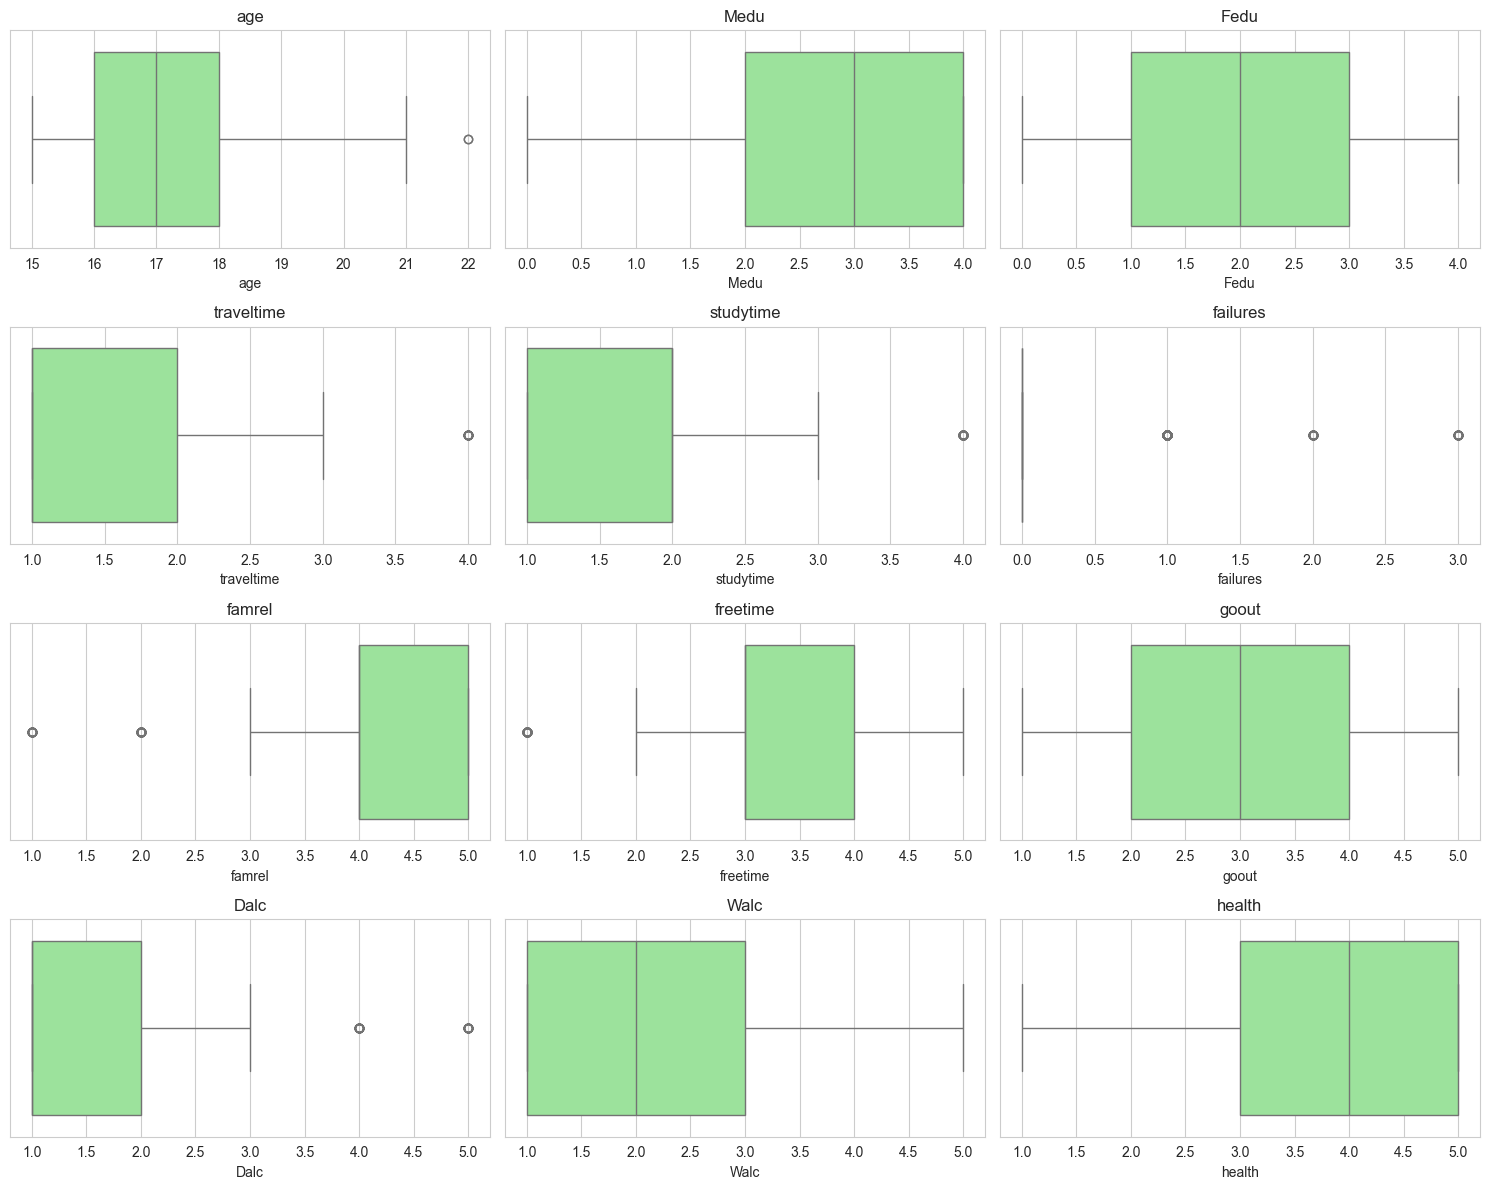

In [13]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

Bivariate Analysis — Features vs Target

In [14]:
corrs_all = df[numeric_cols + ['passed']].corr()['passed'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'passed'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
failures     0.367
age          0.134
absences     0.119
studytime    0.109
goout        0.107
Medu         0.106
Name: passed, dtype: float64


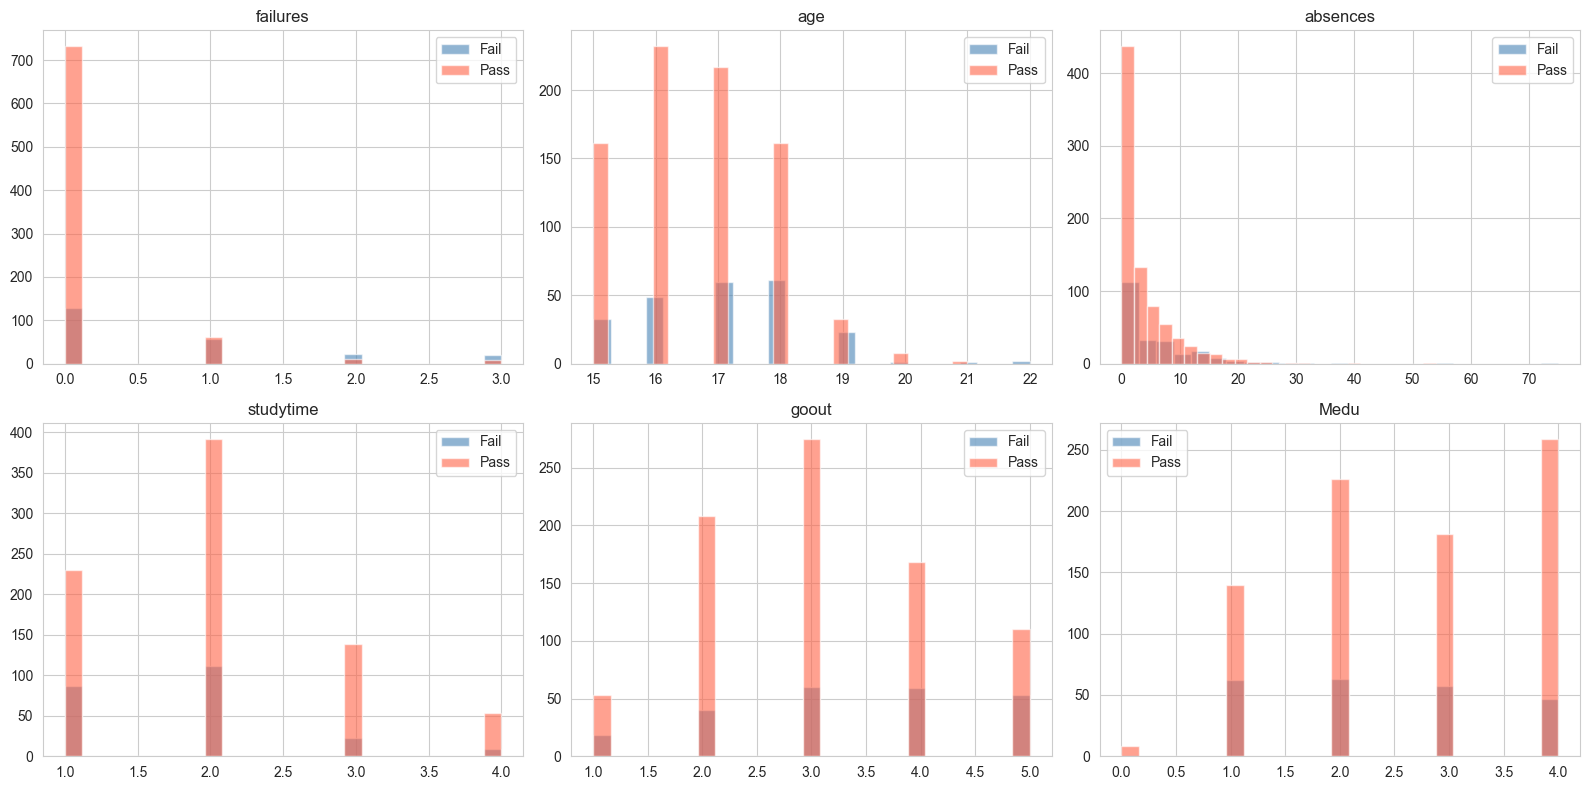

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Fail', 'Pass']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['passed']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [16]:
means = df.groupby('passed')[numeric_cols].mean().T
means.columns = ['Fail', 'Pass']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,Fail,Pass,Difference
absences,5.826,4.042,-1.784
failures,0.717,0.136,-0.581
age,17.039,16.638,-0.402
goout,3.387,3.091,-0.296
Medu,2.378,2.667,0.289
Fedu,2.170,2.450,0.280
Walc,2.470,2.232,-0.237
studytime,1.800,2.018,0.218
Dalc,1.648,1.451,-0.197
freetime,3.326,3.166,-0.160


Correlation Analysis

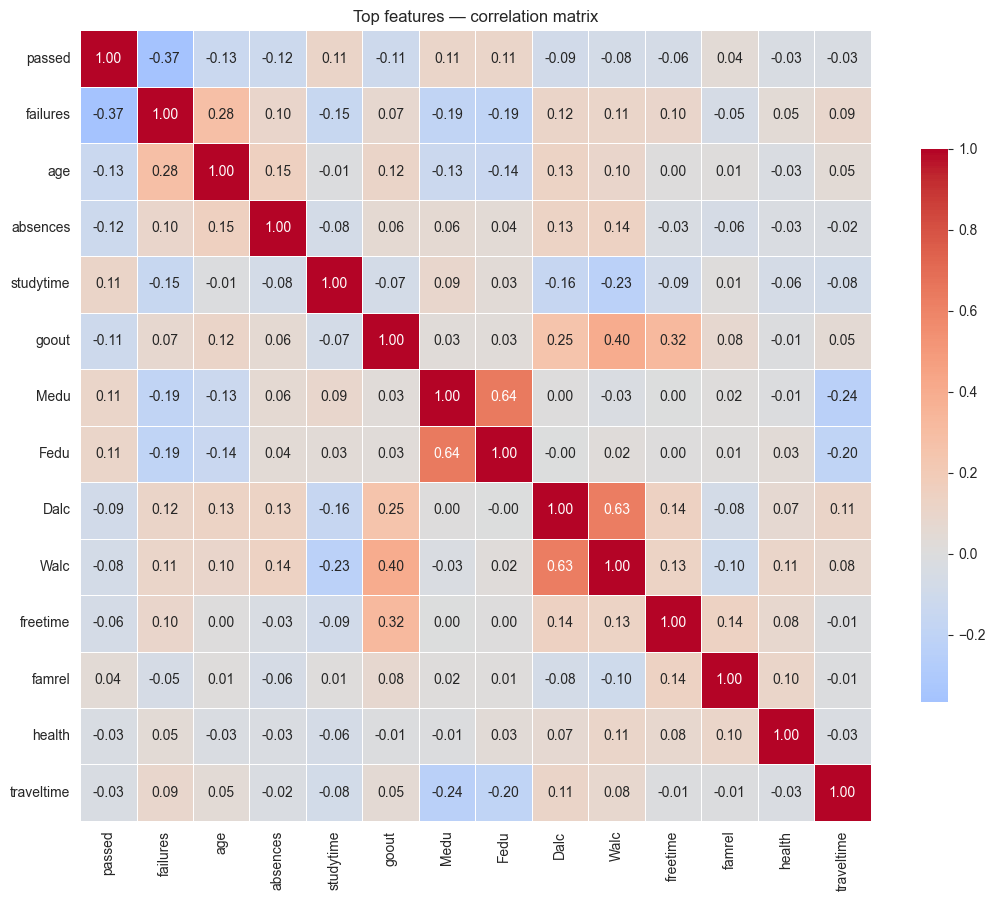

In [17]:
top_numeric = corrs_all.head(15).index.tolist()
if 'passed' not in top_numeric:
    top_numeric.append('passed')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

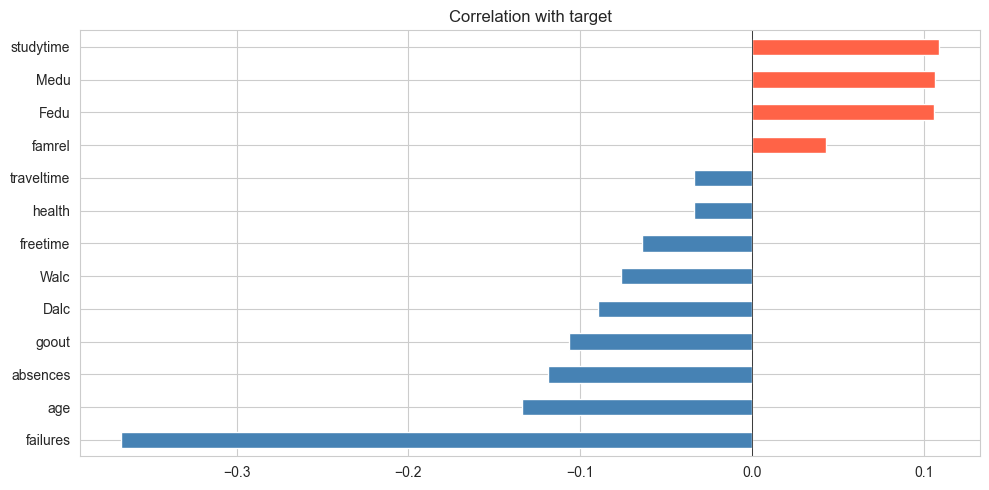

In [18]:
target_corr = df[numeric_cols + ['passed']].corr()['passed'].drop('passed').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

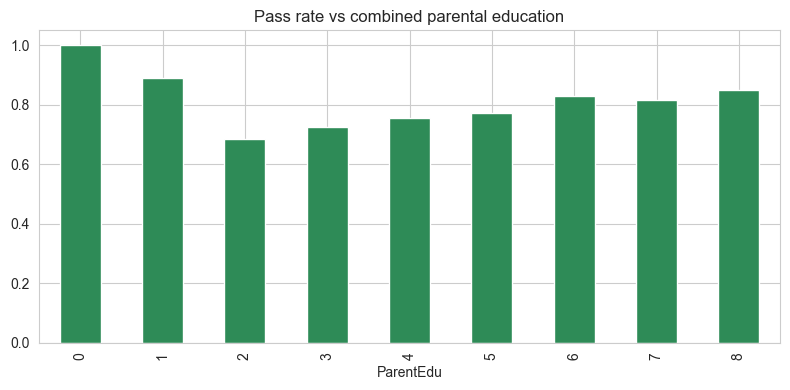

In [19]:
# Education effect: parental education vs pass
fig, ax = plt.subplots(figsize=(8, 4))
df['ParentEdu'] = df['Medu'] + df['Fedu']
df.groupby('ParentEdu')['passed'].mean().plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Pass rate vs combined parental education'); plt.tight_layout(); plt.show()

In [20]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['passed'] == 0).sum()),
        int((df['passed'] == 1).sum()),
        f"{(df['passed'] == 0).sum() / max(1, (df['passed'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,1044
1,Total features,32
2,Class 0 count,230
3,Class 1 count,814
4,Class imbalance ratio,0.28:1
5,Top correlated feature,failures
6,Top correlation value,0.367


Imputation

In [21]:
print('Missing values:', df.isnull().sum().sum())
print('Shape:', df.shape)
df_clean = df.copy()
print('NaN count:', df_clean.isnull().sum().sum())
df_imputed = df_clean.copy()

Missing values: 0
Shape: (1044, 33)
NaN count: 0


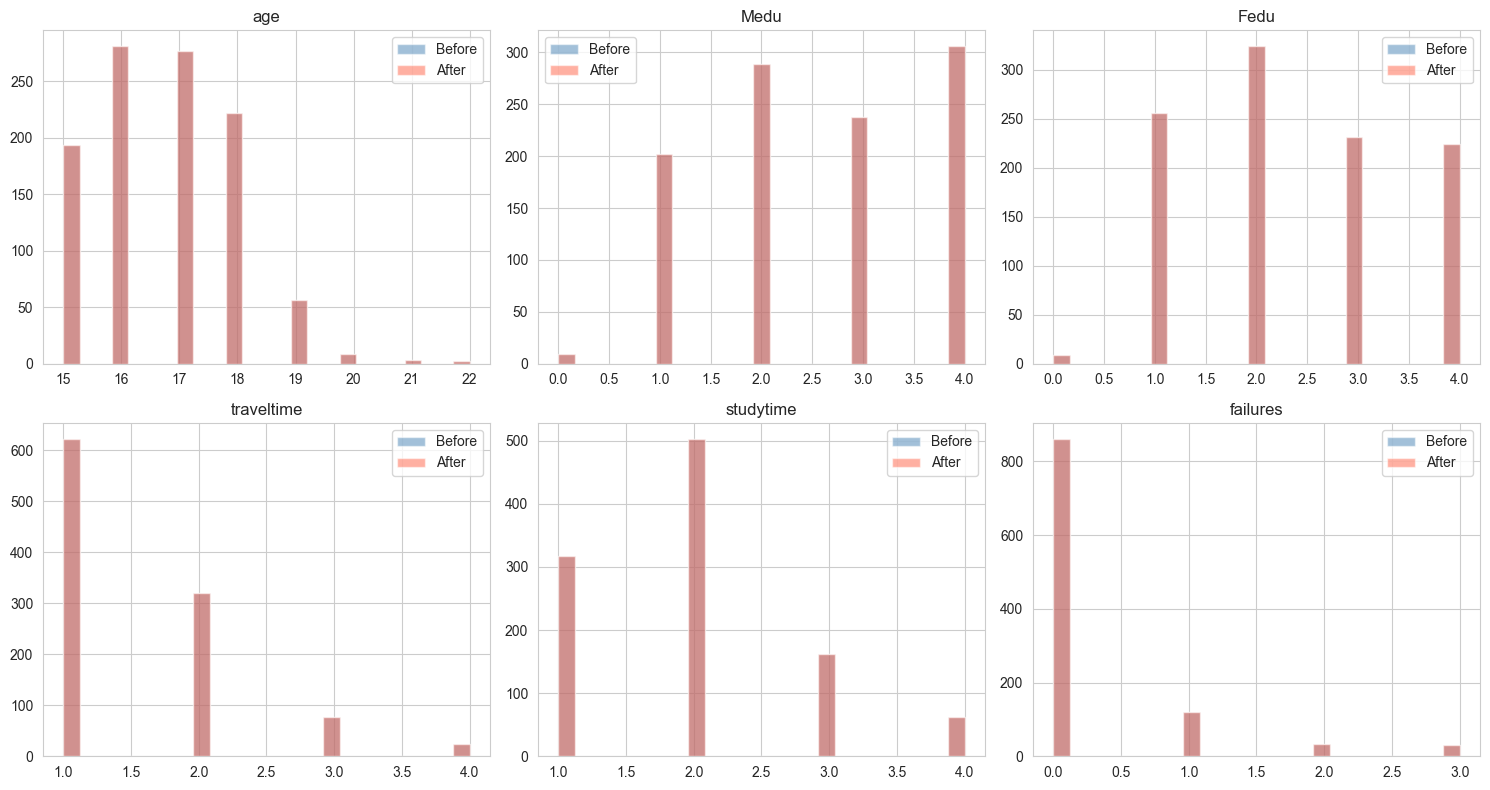

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Select first 6 numeric columns
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6]

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_for_plot):

    # Before imputation
    axes[i].hist(
        df[col].dropna(),
        bins=25,
        alpha=0.5,
        label='Before',
        color='steelblue'
    )

    # After imputation
    axes[i].hist(
        df_imputed[col],
        bins=25,
        alpha=0.5,
        label='After',
        color='tomato'
    )

    axes[i].set_title(col)
    axes[i].legend()

# Remove unused subplots if fewer than 6 columns
for j in range(len(numeric_cols_for_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
from utils import load_data, preprocess_data, create_features
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (1044, 39)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,course,passed,ParentEdu,AlcoholScore,ParentEducation,FamilySupport,StudyAbsenceRatio,SocialActivityScore,AgeGroup
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,math,0,8,2,8,1,0.285714,7,18
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,math,0,2,2,2,1,0.400000,6,17
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,math,1,2,5,2,1,0.181818,5,15-16
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,math,1,6,2,6,1,1.000000,4,15-16
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,math,1,6,3,6,1,0.400000,5,15-16


In [30]:

df_feat.head()
df_feat.shape

(1044, 38)

In [31]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('After encoding:', df_encoded.shape)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course', 'AgeGroup']
After encoding: (1044, 49)


In [32]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/student_cleaned.csv', index=False)
print('Saved -> data/student_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (1044, 49)
Saved -> data/student_cleaned.csv


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,passed,AlcoholScore,ParentEducation,FamilySupport,StudyAbsenceRatio,SocialActivityScore,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,course_portuguese,AgeGroup_17,AgeGroup_18,AgeGroup_19+
0,18,4,4,2,2,0,4,3,4,1,1,3,6,0,2,8,1,0.285714,7,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,1,0
1,17,1,1,1,2,0,5,3,3,1,1,3,4,0,2,2,1,0.400000,6,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0
2,15,1,1,1,2,3,4,3,2,2,3,3,10,1,5,2,1,0.181818,5,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,1,1,1,0,0,0,0,0
3,15,4,2,1,3,0,3,2,2,1,1,5,2,1,2,6,1,1.000000,4,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,1,1,1,1,1,1,0,0,0,0
4,16,3,3,1,2,0,4,3,2,1,2,5,4,1,3,6,1,0.400000,5,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0
